# ALP - Data Science (CEK)

### Kevin Febrian Setiadi - 0706022410001
### Ethan Cannavaro Lauda - 0706022410002
### Casey Daniella Winarto - 0706022410026

Dataset: Telco Customer Churn (Kaggle) <br>
Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [1]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

In [2]:
# Show all columns when displaying the dataframe (no column truncation)
pd.set_option('display.max_columns', None)

In [3]:
# Load Dataset
link = 'https://raw.githubusercontent.com/HEHEfebrian/ALPDS/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(link)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Preliminary Analysis

In [4]:
# Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning

In [5]:
# Check the number of empty string values in each column
df.apply(lambda col: col.astype(str).str.strip().eq("")).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
# Check for invalid or unusual string patterns in each column
df.apply(lambda col: col.astype(str).str.contains(r'\\!s\*\$', regex=True)).sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Display rows that contain empty string values
mask = df.apply(lambda col: col.astype(str).str.strip().eq(""))

df[mask.any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
# Replace empty string values with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

In [9]:
# Fill missing values in TotalCharges using MonthlyCharges × tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

In [10]:
# Recheck for empty string values after replacement
df[mask.any(axis=1)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [11]:
# Convert TotalCharges column to numeric data type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [12]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [13]:
# Display descriptive statistics of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## EDA

### Univariate

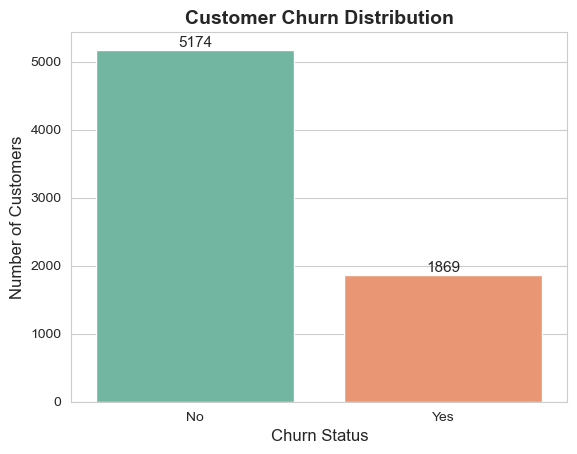

In [14]:
# Visualize customer churn distribution
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )
plt.show()

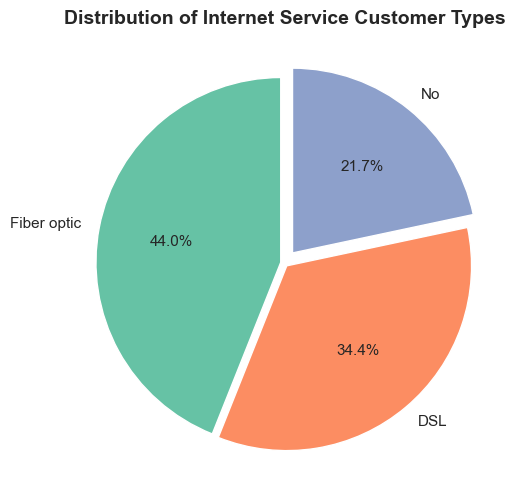

In [15]:
# Visualize the distribution of internet service customer types
data = df['InternetService'].value_counts()

plt.figure(figsize=(10,6))
plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11},
    explode=[0.02, 0.02, 0.07],
    colors=sns.color_palette('Set2')
)
plt.title('Distribution of Internet Service Customer Types', fontsize=14, fontweight='bold')
plt.show()

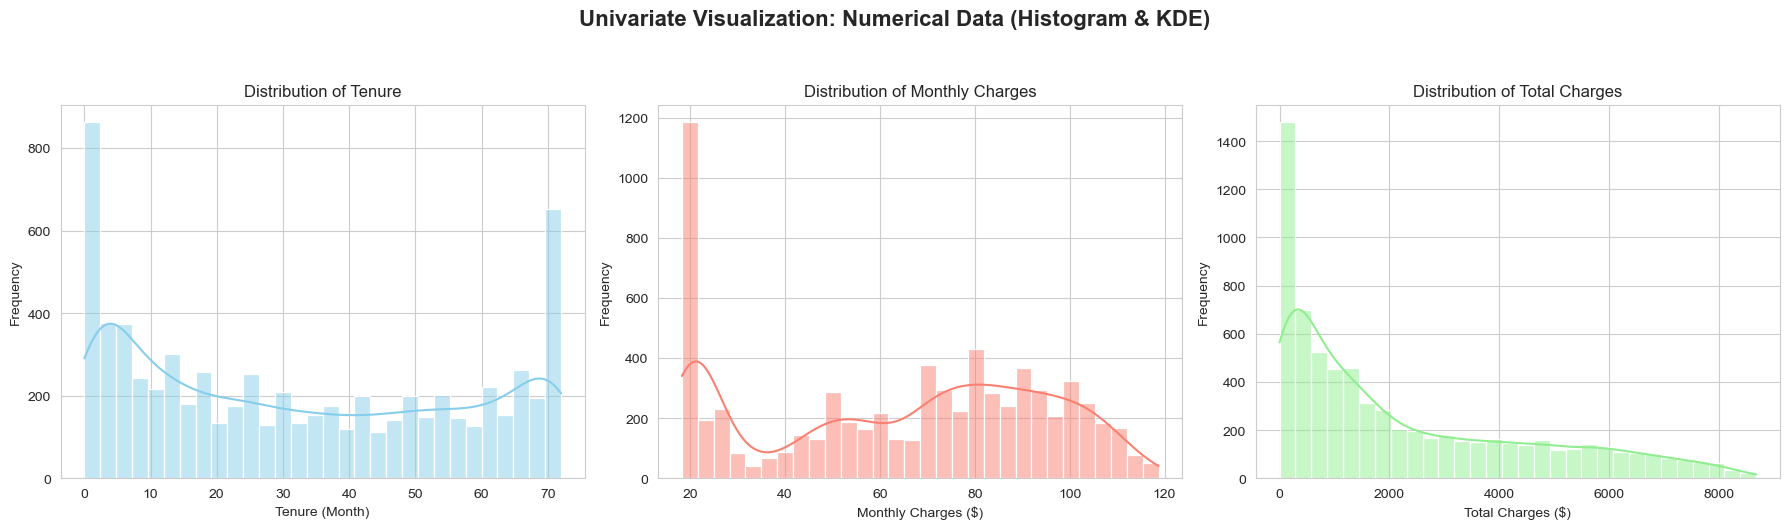

In [16]:
# Visualize the distribution of numerical features using histogram and KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Visualization: Numerical Data (Histogram & KDE)', fontsize=16, fontweight='bold', y=1.05)

# Tenure distribution
sns.histplot(data=df, x='tenure', kde=True, bins=30, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Tenure')
axes[0].set_xlabel('Tenure (Month)')
axes[0].set_ylabel('Frequency')

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', kde=True, bins=30, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Frequency')

# Total charges distribution
sns.histplot(data=df, x='TotalCharges', kde=True, bins=30, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribution of Total Charges')
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Multivariate

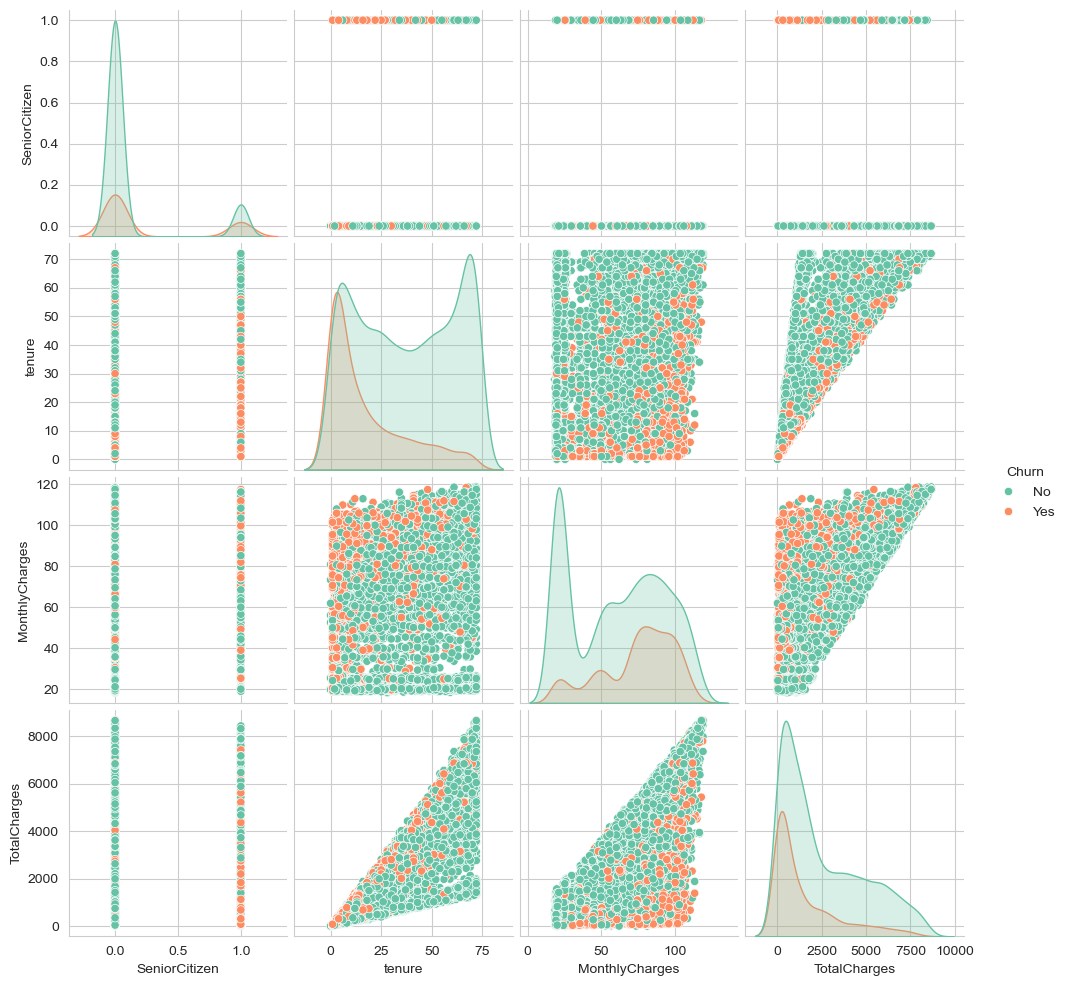

In [17]:
# Visualize relationships between numerical features using pairplot
selected_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges','Churn']
sns.pairplot(df[selected_columns], hue="Churn", palette='Set2')
plt.show()

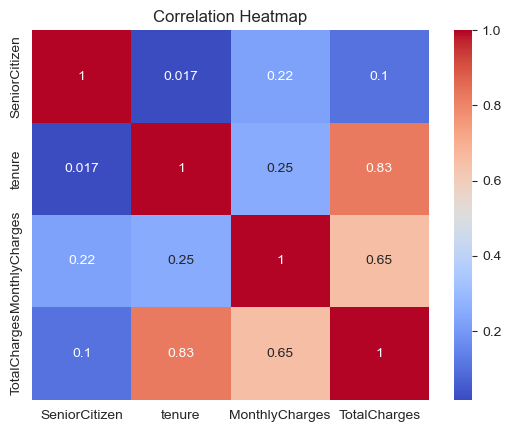

In [18]:
# Visualize correlation between numerical features
sns.heatmap(df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

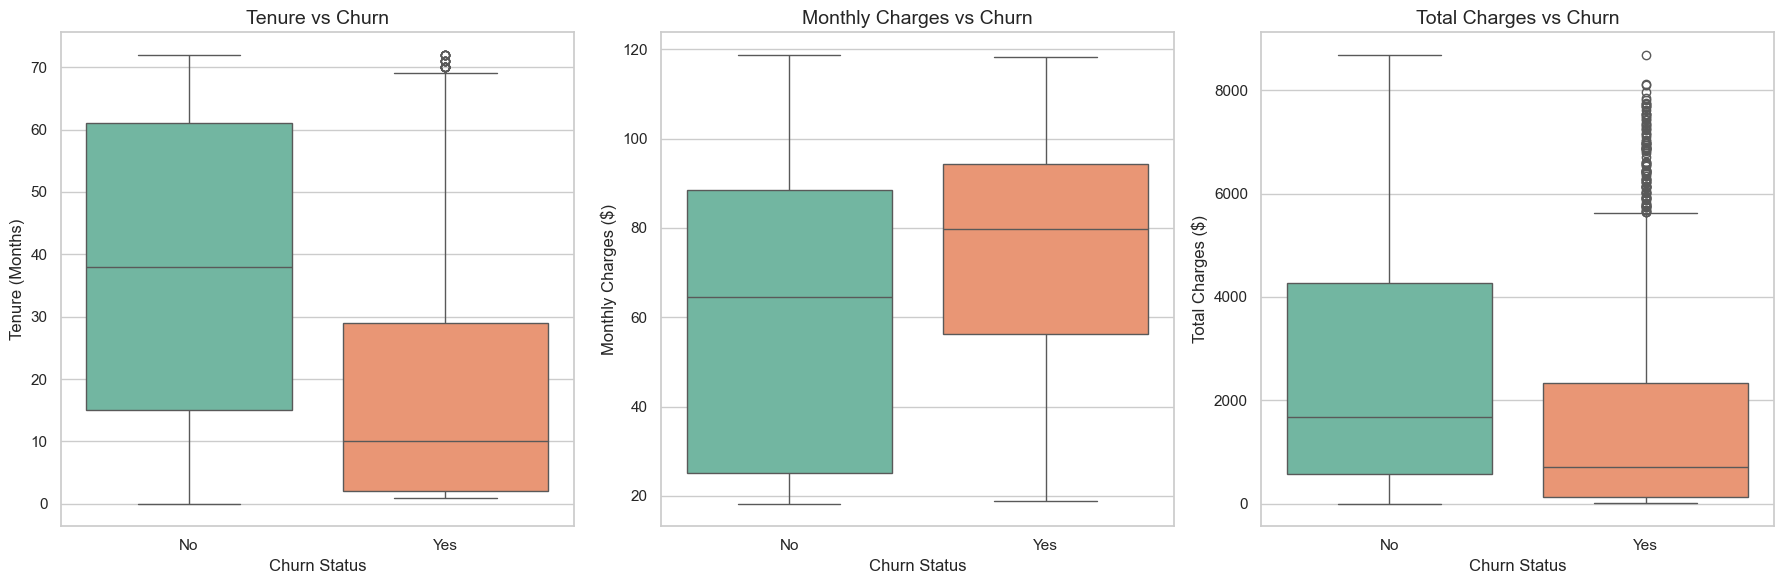

In [19]:
# Compare numerical features based on churn status using boxplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Tenure vs Churn
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Tenure vs Churn", fontsize=14)
axes[0].set_xlabel("Churn Status", fontsize=12)
axes[0].set_ylabel("Tenure (Months)", fontsize=12)

# Monthly Charges vs Churn 
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Monthly Charges vs Churn", fontsize=14)
axes[1].set_xlabel("Churn Status", fontsize=12)
axes[1].set_ylabel("Monthly Charges ($)", fontsize=12)

# Total Charges vs Churn
sns.boxplot(data=df, x="Churn", y="TotalCharges", hue="Churn", ax=axes[2], palette="Set2", legend=False)
axes[2].set_title("Total Charges vs Churn", fontsize=14)
axes[2].set_xlabel("Churn Status", fontsize=12)
axes[2].set_ylabel("Total Charges ($)", fontsize=12)

plt.tight_layout()
plt.show()

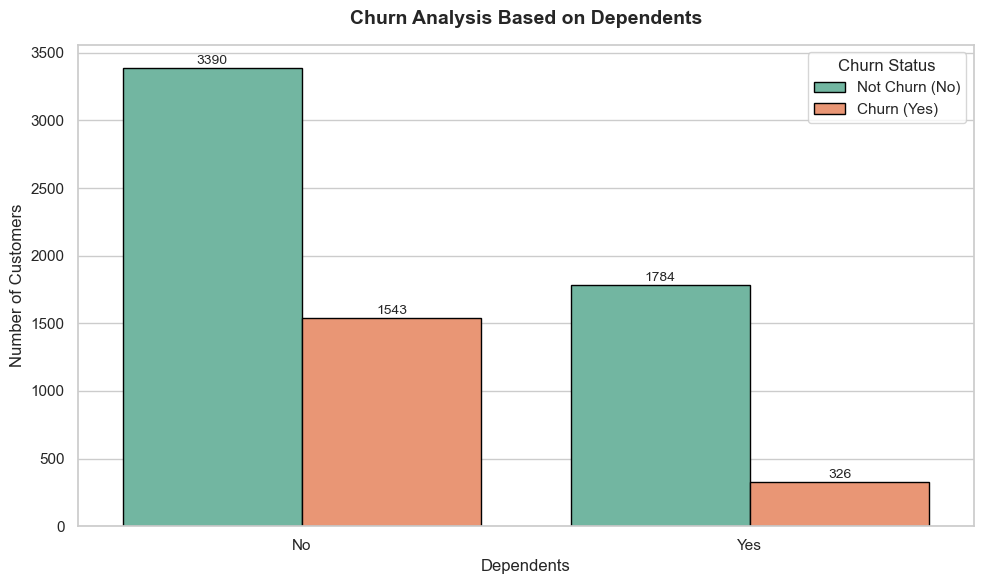

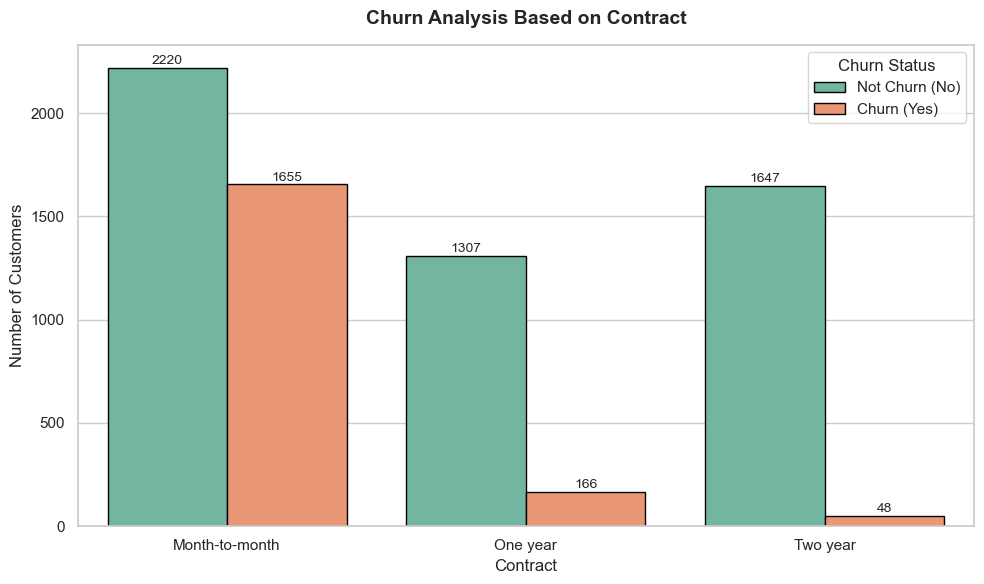

In [20]:
# Analyze churn distribution based on contract type and dependents

features = ["Dependents", "Contract"]

for f in features:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=f, hue='Churn', palette='Set2', edgecolor='black')
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10)
    
    plt.title(f'Churn Analysis Based on {f}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.legend(title='Churn Status', labels=['Not Churn (No)', 'Churn (Yes)'])
    plt.tight_layout()
    plt.show()

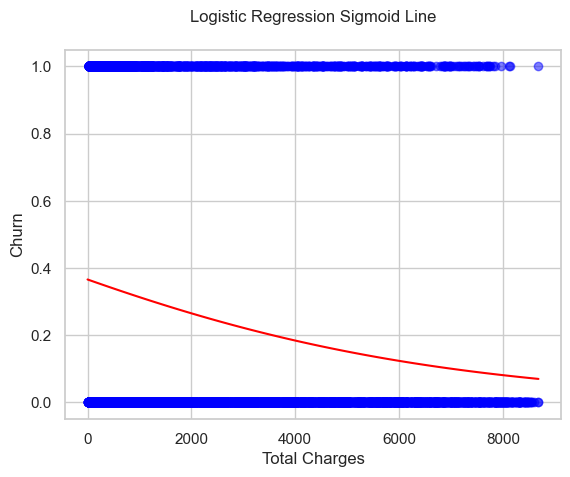

In [21]:
# Visualize the sigmoid curve of Logistic Regression
X_sigmoid = df[['TotalCharges']]
y_sigmoid = df['Churn']
y_sigmoid_numeric = y_sigmoid.map({'Yes': 1, 'No': 0})

modelforvisual = LogisticRegression()
modelforvisual.fit(X_sigmoid, y_sigmoid_numeric)

x_range = np.linspace(df['TotalCharges'].min(), df['TotalCharges'].max(), 100)

sigmoid_func_retail = 1 / (1 + np.exp(-modelforvisual.coef_ * x_range - modelforvisual.intercept_))

plt.plot(x_range, sigmoid_func_retail[0], color='red')
plt.scatter(X_sigmoid, y_sigmoid_numeric, color='blue', alpha=0.5)
plt.title('Logistic Regression Sigmoid Line', pad=20)
plt.xlabel('Total Charges')
plt.ylabel('Churn')
plt.show()

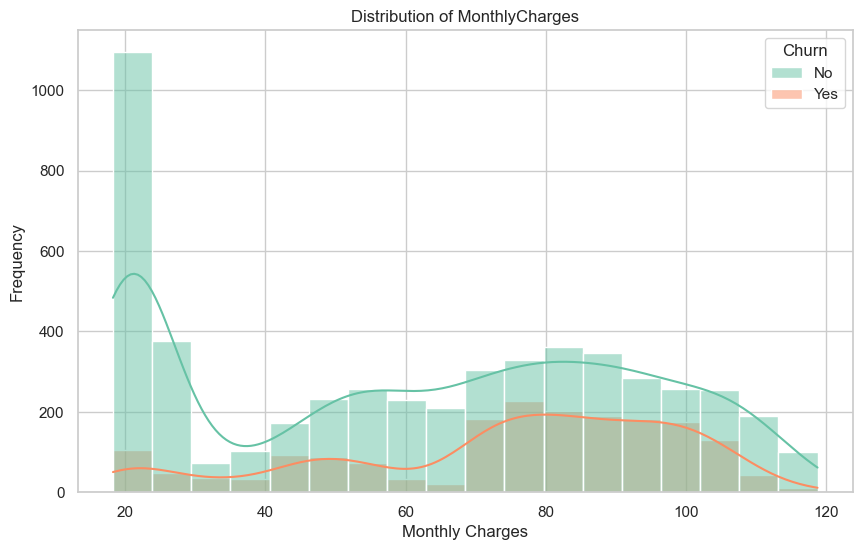

In [22]:
# Visualize the distribution of MonthlyCharges based on churn status
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, palette='Set2')
plt.title(f"Distribution of MonthlyCharges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

## Data Preprocessing

In [23]:
# Apply standardization scaling to numerical feature columns
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [24]:
# Encode binary categorical columns into numerical values
binary_cols = [
    'gender','Partner','Dependents',
    'PhoneService','PaperlessBilling','Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})

In [25]:
# Apply one-hot encoding to categorical feature columns
df = pd.get_dummies(df, columns=[
    'InternetService',
    'Contract',
    'PaymentMethod',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
], drop_first=True)

In [26]:
# Drop customerID column
df.drop('customerID', axis=1, inplace=True)

In [27]:
# Move the 'Churn' column to the last position in the dataframe
df['Churn'] = df.pop('Churn')

In [28]:
# Convert boolean columns to integer type (0 and 1)
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [29]:
# Display the final processed dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Churn
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


## Train Test Split

In [30]:
# Split dataset into training and testing sets
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Add constant
X_train_const = sm.add_constant(X_train)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_const.values, i+1)
    for i in range(len(X_train.columns))
]

print(vif_data)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  Feature           VIF
0                                  gender  1.002473e+00
1                           SeniorCitizen  1.150331e+00
2                                 Partner  1.458444e+00
3                              Dependents  1.380263e+00
4                                  tenure  7.512424e+00
5                            PhoneService           inf
6                        PaperlessBilling  1.213764e+00
7                          MonthlyCharges  8.742996e+02
8                            TotalCharges  1.085479e+01
9             InternetService_Fiber optic  1.499894e+02
10                     InternetService_No  3.467706e+07
11                      Contract_One year  1.635009e+00
12                      Contract_Two year  2.620571e+00
13  PaymentMethod_Credit card (automatic)  1.562759e+00
14         PaymentMethod_Electronic check  1.942289e+00
15             PaymentMethod_Mailed check  1.849030e+00
16         MultipleLines_No phone service       

In [32]:
# Drop columns with high VIF values (greater than 10)
column_multicol = [
    'MultipleLines_No phone service',
    'InternetService_No',                    
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'TotalCharges',
    'InternetService_Fiber optic',
    'MultipleLines_Yes',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

X_train.drop(columns=column_multicol, inplace=True)
X_test.drop(columns=column_multicol, inplace=True)

print("Total columns after removing multicollinearity:", X_train.shape[1])
print("List of remaining columns:\n", X_train.columns.tolist())

Total columns after removing multicollinearity: 13
List of remaining columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [33]:
# Apply SMOTE to handle class imbalance in the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


## Model Training

In [34]:
# Hyperparameter tuning for Logistic Regression using GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_log_smote = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

tuning_log = grid_log.fit(X_train, y_train)
tuning_log_smote = grid_log_smote.fit(X_train_smote, y_train_smote)

print("Best Params Logistic Regression:")
print(tuning_log.best_params_)
print("Best Params Logistic Regression (SMOTE):")
print(tuning_log_smote.best_params_)

Best Params Logistic Regression:
{'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}
Best Params Logistic Regression (SMOTE):
{'C': 10, 'class_weight': None, 'max_iter': 1000, 'solver': 'liblinear'}


In [35]:
# Logistic Regression Model
log_model = tuning_log.best_estimator_
log_model_smote = tuning_log_smote.best_estimator_

In [36]:
# Hyperparameter tuning for K-NN using GridSearchCV
param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21,23,25,27,29],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_knn_smote = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

tuning_knn = grid_knn.fit(X_train, y_train)
tuning_knn_smote = grid_knn_smote.fit(X_train_smote, y_train_smote)

print("Best Params K-NN:")
print(tuning_knn.best_params_)
print("Best Params K-NN (SMOTE):")
print(tuning_knn_smote.best_params_)

Best Params K-NN:
{'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best Params K-NN (SMOTE):
{'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}


In [37]:
# K-NN Model
knn_model = tuning_knn.best_estimator_
knn_model_smote = tuning_knn_smote.best_estimator_

In [38]:
# Hyperparameter tuning for NB using GridSearchCV
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_nb_smote = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

tuning_nb = grid_nb.fit(X_train, y_train)
tuning_nb_smote = grid_nb_smote.fit(X_train_smote, y_train_smote)

print("Best Params NB:")
print(tuning_nb.best_params_)
print("Best Params NB (SMOTE):")
print(tuning_nb_smote.best_params_)

Best Params NB:
{'var_smoothing': 0.12328467394420659}
Best Params NB (SMOTE):
{'var_smoothing': 0.008111308307896872}


In [39]:
# Naive Bayes Model
nb_model = tuning_nb.best_estimator_
nb_model_smote = tuning_nb_smote.best_estimator_

In [40]:
# Hyperparameter tuning for Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf_smote = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

tuning_rf = grid_rf.fit(X_train, y_train)
tuning_rf_smote = grid_rf_smote.fit(X_train_smote, y_train_smote)

print("Best Params Random Forest:")
print(tuning_rf.best_params_)
print("Best Params Random Forest (SMOTE):")
print(tuning_rf_smote.best_params_)

Best Params Random Forest:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Params Random Forest (SMOTE):
{'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [41]:
# Random Forest Model
rf_model = tuning_rf.best_estimator_
rf_model_smote = tuning_rf_smote.best_estimator_

## Prediction

In [42]:
# Generate predictions using trained models
y_pred_log = log_model.predict(X_test)
y_pred_log_smote = log_model_smote.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_knn_smote = knn_model_smote.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_nb_smote = nb_model_smote.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_smote = rf_model_smote.predict(X_test)

comparison_table = pd.DataFrame({
    "y_test": y_test.reset_index(drop=True),
    "y_pred_log": y_pred_log,
    "y_pred_log_smote": y_pred_log_smote,
    "y_pred_knn": y_pred_knn,
    "y_pred_knn_smote": y_pred_knn_smote,
    "y_pred_nb": y_pred_nb,
    "y_pred_nb_smote": y_pred_nb_smote,
    "y_pred_rf": y_pred_rf,
    "y_pred_rf_smote": y_pred_rf_smote
})


comparison_table.head()

,y_test,y_pred_log,y_pred_log_smote,y_pred_knn,y_pred_knn_smote,y_pred_nb,y_pred_nb_smote,y_pred_rf,y_pred_rf_smote
0,1,1,1,1,1,1,1,1,1
1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1
4,0,0,0,0,0,0,0,0,0


## Evaluation

In [43]:
# Evaluate Logistic Regression model (non SMOTE)
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix using Logistic Regression\n", cm_log)

accuracy_log = accuracy_score(y_test, y_pred_log)
print("Accuracy Score:", accuracy_log)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_log))

# Evaluate K-Nearest Neighbors model (non SMOTE)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix using K-Nearest Neighbour\n", cm_knn)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy Score:", accuracy_knn)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_knn))  

# Evaluate Naive Bayes model (non SMOTE)
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix using Naive Bayes\n", cm_nb)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy Score:", accuracy_nb)
print("Classification Report using Naive Bayes\n", classification_report(y_test, y_pred_nb))

# Evaluate Random Forest model (non SMOTE)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix using Random Forest\n", cm_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Score:", accuracy_rf)
print("Classification Report using Random Forest\n", classification_report(y_test, y_pred_rf))

Confusion Matrix using Logistic Regression
 [[753 283]
 [ 61 312]]
Accuracy Score: 0.7558552164655784
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.93      0.73      0.81      1036
           1       0.52      0.84      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409


Confusion Matrix using K-Nearest Neighbour
 [[933 103]
 [181 192]]
Accuracy Score: 0.7984386089425124
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.51      0.57       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix using Naive Bayes
 [[810 226]
 [ 92 281]]
Accuracy Score: 0.774

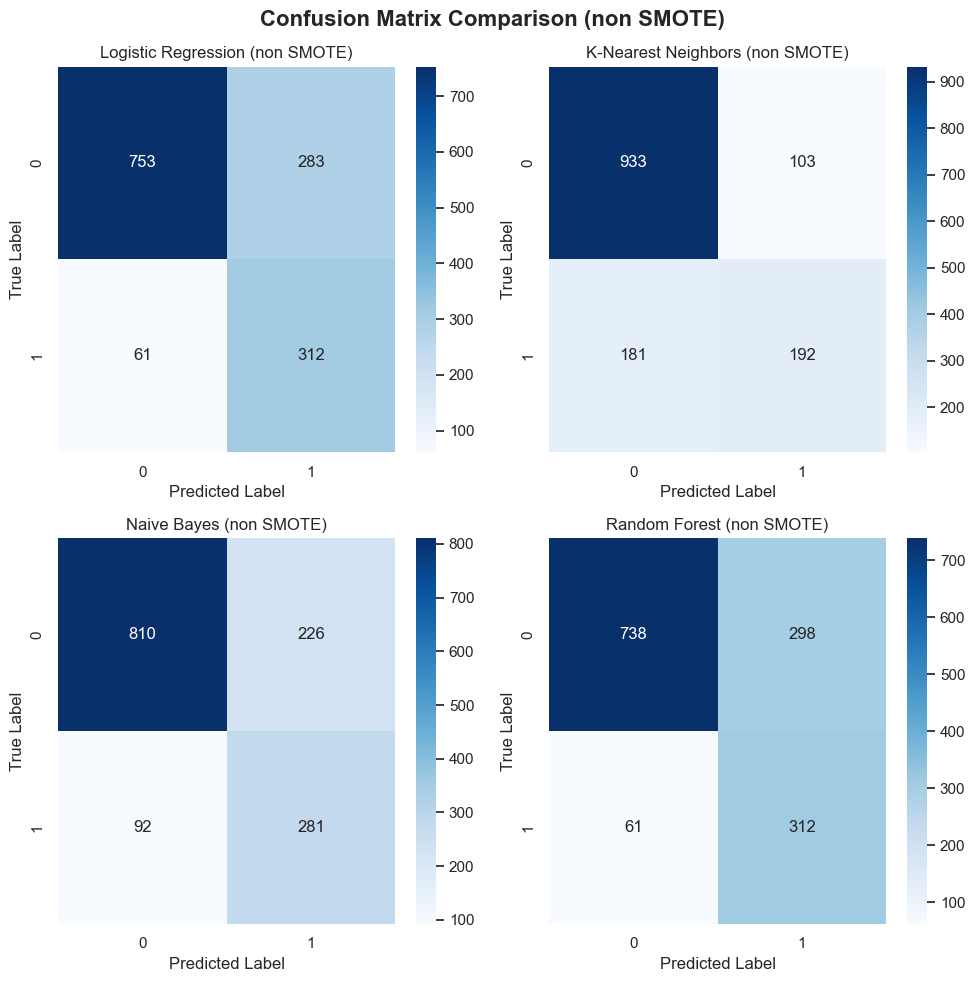

In [44]:
# Visualize confusion matrices for all models (non SMOTE)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])

axes[0, 0].set_title('Logistic Regression (non SMOTE)')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# K-Nearest Neighbors
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])

axes[0, 1].set_title('K-Nearest Neighbors (non SMOTE)')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Naive Bayes
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",ax=axes[1, 0])

axes[1, 0].set_title('Naive Bayes (non SMOTE)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1])

axes[1, 1].set_title('Random Forest (non SMOTE)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

fig.suptitle('Confusion Matrix Comparison (non SMOTE)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
# Evaluate Logistic Regression model (SMOTE)
cm_log_smote = confusion_matrix(y_test, y_pred_log_smote)
print("Confusion Matrix using Logistic Regression\n", cm_log_smote)

accuracy_log_smote = accuracy_score(y_test, y_pred_log_smote)
print("Accuracy Score:", accuracy_log_smote)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_log_smote))

# Evaluate K-Nearest Neighbors model (SMOTE)
cm_knn_smote = confusion_matrix(y_test, y_pred_knn_smote)
print("\nConfusion Matrix using K-Nearest Neighbour\n", cm_knn_smote)

accuracy_knn_smote = accuracy_score(y_test, y_pred_knn_smote)
print("Accuracy Score:", accuracy_knn_smote)
print("Precision, Recall, F1-Score:\n", classification_report(y_test, y_pred_knn_smote))

# Evaluate Naive Bayes model (SMOTE)
cm_nb_smote = confusion_matrix(y_test, y_pred_nb_smote)
print("\nConfusion Matrix using Naive Bayes\n", cm_nb_smote)

accuracy_nb_smote = accuracy_score(y_test, y_pred_nb_smote)
print("Accuracy Score:", accuracy_nb_smote)
print("Classification Report using Naive Bayes\n", classification_report(y_test, y_pred_nb_smote))

# Evaluate Random Forest model (SMOTE)
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
print("\nConfusion Matrix using Random Forest\n", cm_rf_smote)

accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
print("Accuracy Score:", accuracy_rf_smote)
print("Classification Report using Random Forest\n", classification_report(y_test, y_pred_rf_smote))

Confusion Matrix using Logistic Regression
 [[737 299]
 [ 58 315]]
Accuracy Score: 0.7466288147622427
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.93      0.71      0.81      1036
           1       0.51      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.75      0.76      1409


Confusion Matrix using K-Nearest Neighbour
 [[727 309]
 [ 88 285]]
Accuracy Score: 0.7182398864442867
Precision, Recall, F1-Score:
               precision    recall  f1-score   support

           0       0.89      0.70      0.79      1036
           1       0.48      0.76      0.59       373

    accuracy                           0.72      1409
   macro avg       0.69      0.73      0.69      1409
weighted avg       0.78      0.72      0.73      1409


Confusion Matrix using Naive Bayes
 [[683 353]
 [ 48 325]]
Accuracy Score: 0.715

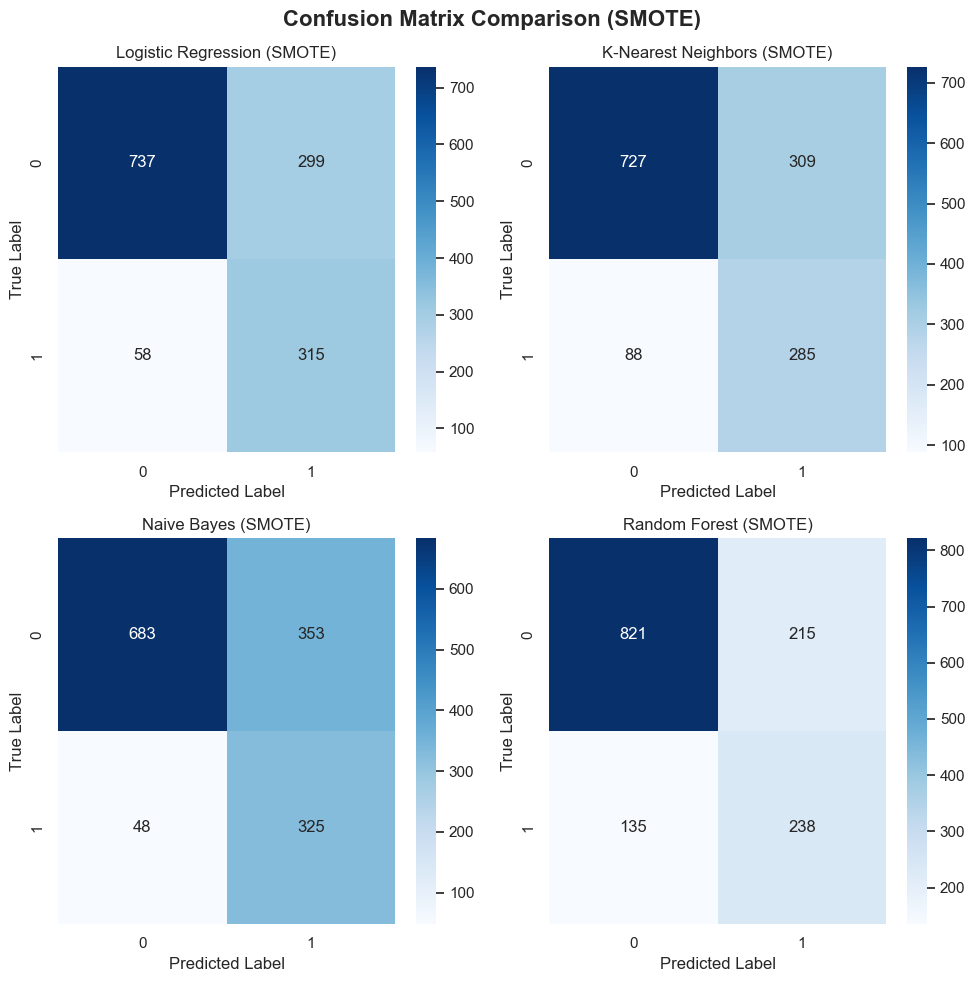

In [46]:
# Visualize confusion matrices for all models (SMOTE)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Logistic Regression
sns.heatmap(cm_log_smote, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])

axes[0, 0].set_title('Logistic Regression (SMOTE)')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# K-Nearest Neighbors
sns.heatmap(cm_knn_smote, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])

axes[0, 1].set_title('K-Nearest Neighbors (SMOTE)')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# Naive Bayes
sns.heatmap(cm_nb_smote, annot=True, fmt="d", cmap="Blues",ax=axes[1, 0])

axes[1, 0].set_title('Naive Bayes (SMOTE)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Random Forest
sns.heatmap(cm_rf_smote, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1])

axes[1, 1].set_title('Random Forest (SMOTE)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

fig.suptitle('Confusion Matrix Comparison (SMOTE)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Based on the evaluation results of the classification models, the non-SMOTE K-Nearest Neighbour (K-NN) model achieved the highest accuracy score of 79.84%, with a precision of 0.65 and an F1-score of 0.57 for the minority class (churn). However, Logistic Regression and Naive Bayes produced higher recall values for the minority class, reaching 0.84 and 0.75 respectively, indicating better capability in detecting positive cases compared to K-NN. Meanwhile, the non-SMOTE Random Forest model also achieved a high recall of 0.84 for class 1, although its overall accuracy and precision were lower than those of K-NN. These results indicate that each model has different strengths depending on the evaluation focus, whether prioritizing overall accuracy or the ability to detect minority class instances.

### After applying the SMOTE technique, most models showed improved recall performance for the minority class, particularly Naive Bayes with a recall of 0.87 and Logistic Regression with 0.84. However, the increase in recall was accompanied by a decrease in overall accuracy for several models, especially K-NN and Naive Bayes. The Random Forest model with SMOTE produced relatively balanced results, achieving an accuracy of 75.44%, a precision of 0.53, and a recall of 0.64 for churn customers. Overall, the implementation of SMOTE improved the models’ sensitivity toward the minority class but tended to reduce overall accuracy. Therefore, the selection of the best model should depend on the main objective of the analysis, whether prioritizing overall accuracy or maximizing minority class detection.